# 03 — Classical ML Model
**Employee Feedback Intelligence Platform**

Picks up from `data/processed/cleaned.csv` produced by Notebook 02.

Steps:
1. Load cleaned data
2. TF-IDF feature engineering
3. Stratified 70 / 15 / 15 train / val / test split
4. Benchmark **Logistic Regression**, **LinearSVC**, **Random Forest**
5. GridSearchCV tuning on the best-performing model
6. Confusion matrix & top-feature analysis
7. Save model + vectorizer → `models/`


In [1]:
import os, warnings, joblib, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)


RANDOM_STATE = 42



In [2]:
df = pd.read_csv('../data/processed/cleaned.csv')
print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print()
print('Sentiment distribution:')
counts = df['sentiment'].value_counts()
print(counts)
print()
print('Class balance (%):')
print((counts / len(df) * 100).round(1))
df.head(3)

Loaded : 805,051 rows × 4 columns
Columns: ['text', 'clean_text', 'sentiment', 'overall_rating']

Sentiment distribution:
sentiment
Positive    490496
Neutral     185745
Negative    128810
Name: count, dtype: int64

Class balance (%):
sentiment
Positive    60.9
Neutral     23.1
Negative    16.0
Name: count, dtype: float64


,text,clean_text,sentiment,overall_rating
0,Very friendly and welcoming to new staff. Easy...,friendly welcoming new staff easy going ethic ...,Negative,2
1,"Friendly, helpful and hard-working colleagues ...",friendly helpful hard working colleague poor s...,Negative,2
2,Easy to get the job even without experience in...,easy get job even without experience finance l...,Negative,1


## 2. Feature Engineering — TF-IDF

We convert `clean_text` into a sparse numeric matrix using TF-IDF.

| Parameter | Value | Rationale |
|---|---|---|
| `max_features` | 30 000 | Caps vocabulary; balances coverage vs memory |
| `ngram_range` | (1, 2) | Unigrams + bigrams capture short phrases |
| `sublinear_tf` | True | Log-scale TF reduces dominance of very common terms |
| `min_df` | 2 | Drops hapax legomena (noise reduction) |


In [3]:
tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
)

X = df['clean_text'].fillna('')
y = df['sentiment']

print(f'Samples : {len(X):,}')
print(f'Classes : {sorted(y.unique().tolist())}')

Samples : 805,051
Classes : ['Negative', 'Neutral', 'Positive']


## 3. Stratified Train / Val / Test Split  (70 / 15 / 15)

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train,
    test_size=0.15 / 0.85,          # ~15 % of original
    random_state=RANDOM_STATE, stratify=y_train
)

print(f'Train : {len(X_train_raw):,}')
print(f'Val   : {len(X_val_raw):,}')
print(f'Test  : {len(X_test_raw):,}')

# Fit TF-IDF on TRAIN only — prevent leakage
X_train = tfidf.fit_transform(X_train_raw)
X_val   = tfidf.transform(X_val_raw)
X_test  = tfidf.transform(X_test_raw)
print(f'\nTF-IDF matrix: {X_train.shape[0]:,} rows × {X_train.shape[1]:,} features')

Train : 563,535
Val   : 120,758
Test  : 120,758

TF-IDF matrix: 563,535 rows × 30,000 features


## 4. Benchmark — Three Classifiers

| Model | Why we include it |
|---|---|
| **Logistic Regression** | Fast, highly interpretable, strong text baseline |
| **LinearSVC** | Typically best on high-dimensional sparse features |
| **Random Forest** | Non-linear ensemble; captures feature interactions |


In [5]:
def evaluate_model(name, clf, X_tr, y_tr, X_vl, y_vl):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_vl)
    acc = accuracy_score(y_vl, y_pred)
    f1  = f1_score(y_vl, y_pred, average='macro')
    print(f'{name:<26}  acc={acc:.4f}   macro-F1={f1:.4f}')
    return clf, acc, f1, y_pred

models_cfg = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0,
                                               random_state=RANDOM_STATE),
    'LinearSVC'           : LinearSVC(C=1.0, max_iter=3000,
                                      random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=30,
                                                   n_jobs=-1,
                                                   random_state=RANDOM_STATE),
}

results = {}
print('=== Validation Performance ===')
for name, clf in models_cfg.items():
    m, acc, f1, preds = evaluate_model(name, clf, X_train, y_train, X_val, y_val)
    results[name] = {'model': m, 'acc': acc, 'f1': f1, 'val_preds': preds}

=== Validation Performance ===
Logistic Regression         acc=0.6911   macro-F1=0.5655
LinearSVC                   acc=0.6855   macro-F1=0.5476
Random Forest               acc=0.6258   macro-F1=0.3220


## 6. Hyperparameter Tuning — LinearSVC

LinearSVC typically leads on text classification tasks.  
I tune the regularisation strength `C` with 5-fold stratified CV.


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params : {'C': 1}
Best CV F1  : 0.5480


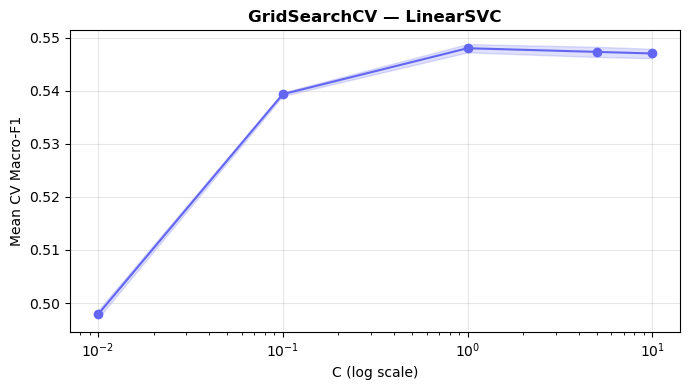

 Saved assets/classical_gridsearch.png


In [7]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
    param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')
best_clf = grid.best_estimator_

# CV curve
cv_df = pd.DataFrame(grid.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cv_df['param_C'].astype(float), cv_df['mean_test_score'],
        marker='o', color='#6366f1')
ax.fill_between(
    cv_df['param_C'].astype(float),
    cv_df['mean_test_score'] - cv_df['std_test_score'],
    cv_df['mean_test_score'] + cv_df['std_test_score'],
    alpha=0.2, color='#6366f1'
)
ax.set_xscale('log')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Mean CV Macro-F1')
ax.set_title('GridSearchCV — LinearSVC', fontweight='bold'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/classical_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved assets/classical_gridsearch.png')

## 7. Final Evaluation on Held-Out Test Set

In [8]:
y_pred_test = best_clf.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='macro')

print(f'Test Accuracy : {acc_test:.4f}')
print(f'Test Macro-F1 : {f1_test:.4f}')
print()
print(classification_report(y_test, y_pred_test))

Test Accuracy : 0.6874
Test Macro-F1 : 0.5493

              precision    recall  f1-score   support

    Negative       0.64      0.54      0.59     19321
     Neutral       0.42      0.18      0.25     27862
    Positive       0.73      0.92      0.81     73575

    accuracy                           0.69    120758
   macro avg       0.60      0.55      0.55    120758
weighted avg       0.64      0.69      0.65    120758



## 8. Confusion Matrix (Test Set)

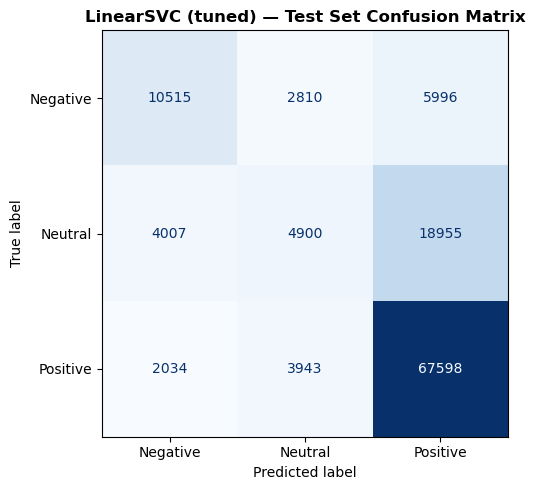

 Saved assets/classical_confusion_matrix.png


In [9]:
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred_test, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('LinearSVC (tuned) — Test Set Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/classical_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved assets/classical_confusion_matrix.png')

## 9. Most Informative TF-IDF Features per Class

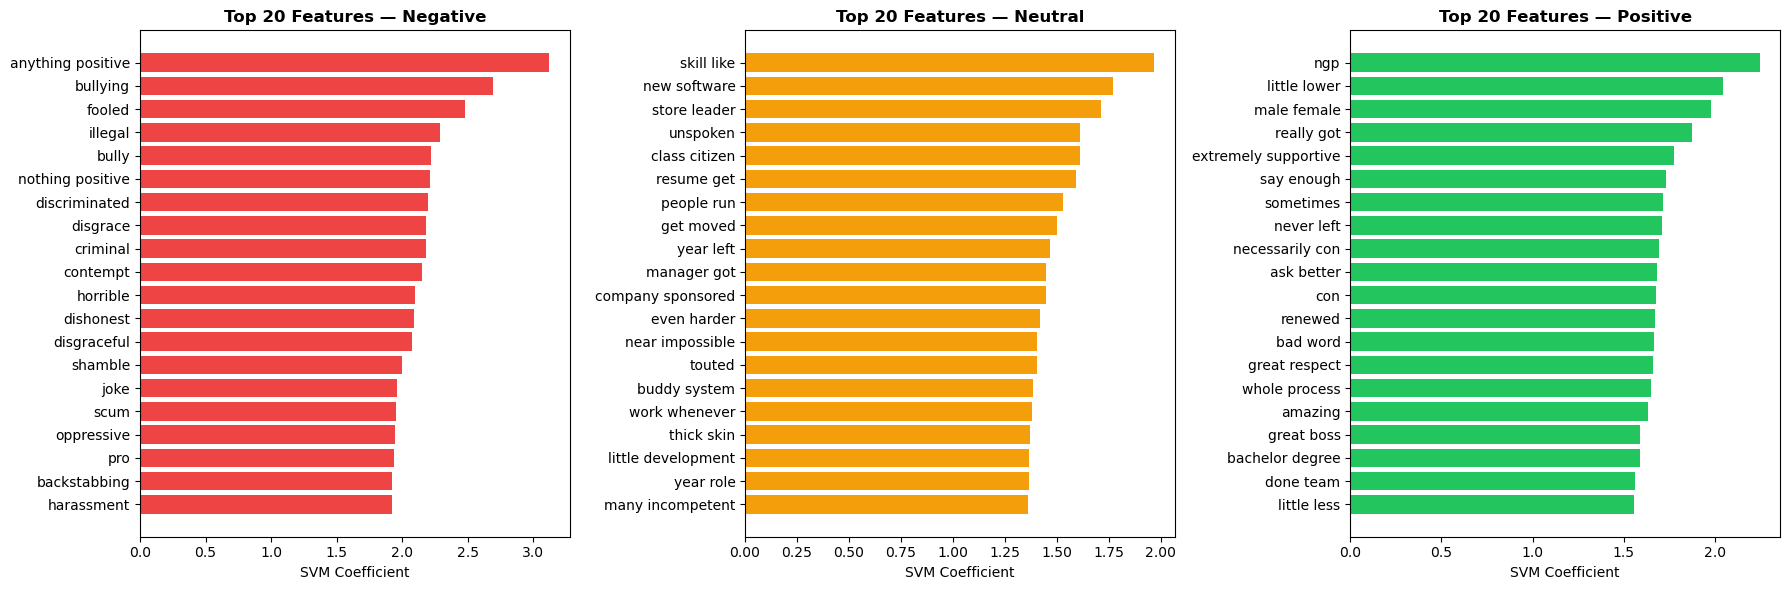

✅ Saved assets/classical_top_features.png


In [10]:
feature_names = np.array(tfidf.get_feature_names_out())
color_map     = {'Negative': '#ef4444', 'Neutral': '#f59e0b', 'Positive': '#22c55e'}

fig, axes = plt.subplots(1, len(best_clf.classes_), figsize=(18, 6))
for ax, cls_name, coef in zip(axes, best_clf.classes_, best_clf.coef_):
    top_idx = np.argsort(coef)[-20:]
    ax.barh(feature_names[top_idx], coef[top_idx],
            color=color_map.get(cls_name, '#6366f1'))
    ax.set_title(f'Top 20 Features — {cls_name}', fontweight='bold')
    ax.set_xlabel('SVM Coefficient')

plt.tight_layout()
plt.savefig('../assets/classical_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved assets/classical_top_features.png')

## 10. Save Model, Vectorizer & Metrics

In [14]:
import os
os.makedirs('../models', exist_ok=True)

# Re-derive names in case the benchmark cell didn't complete
names = list(results.keys())

joblib.dump(best_clf, '../models/classical_model.pkl')
joblib.dump(tfidf,   '../models/tfidf_vectorizer.pkl')

metrics = {
    'model'         : 'LinearSVC (tuned)',
    'test_accuracy' : round(float(acc_test), 4),
    'test_macro_f1' : round(float(f1_test),  4),
    'best_C'        : grid.best_params_['C'],
    'val_results'   : {
        n: {'acc': round(results[n]['acc'], 4), 'f1': round(results[n]['f1'], 4)}
        for n in names
    },
}
with open('../models/classical_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ models/classical_model.pkl')
print('✅ models/tfidf_vectorizer.pkl')
print('✅ models/classical_metrics.json')
print()


✅ models/classical_model.pkl
✅ models/tfidf_vectorizer.pkl
✅ models/classical_metrics.json

